In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('df_train.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(["symbol", "date"])

In [21]:
# ── 1. Returns ────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("RETURN ENGINEERING")
print("="*60)

df['ret_1d']  = df.groupby('symbol')['close'].pct_change(1)
df['ret_2d']  = df.groupby('symbol')['close'].pct_change(2)
df['ret_5d']  = df.groupby('symbol')['close'].pct_change(5)
df['ret_10d'] = df.groupby('symbol')['close'].pct_change(10)
df['ret_20d'] = df.groupby('symbol')['close'].pct_change(20)

# Forward returns (what we're trying to predict)
df['fwd_1d']  = df.groupby('symbol')['ret_1d'].shift(-1)
df['fwd_5d']  = df.groupby('symbol')['ret_5d'].shift(-5)

print("Return stats (1-day):")
print(df['ret_1d'].describe())


RETURN ENGINEERING
Return stats (1-day):
count    100500.000000
mean          0.000534
std           0.025425
min          -0.346491
25%          -0.011947
50%           0.000000
75%           0.013100
max           0.327778
Name: ret_1d, dtype: float64


In [22]:
# ── 2. Technical Features ─────────────────────────────────────────────────────
print("\n" + "="*60)
print("TECHNICAL FEATURE ENGINEERING")
print("="*60)

g = df.groupby('symbol')

# Momentum
df['mom_5']  = g['close'].transform(lambda x: x.pct_change(5))
df['mom_10'] = g['close'].transform(lambda x: x.pct_change(10))
df['mom_20'] = g['close'].transform(lambda x: x.pct_change(20))

# Moving averages & crossovers
df['sma_5']  = g['close'].transform(lambda x: x.rolling(5).mean())
df['sma_20'] = g['close'].transform(lambda x: x.rolling(20).mean())
df['sma_cross'] = df['sma_5'] / df['sma_20'] - 1  # >0 means bullish crossover

# Volatility
df['vol_5']  = g['ret_1d'].transform(lambda x: x.rolling(5).std())
df['vol_20'] = g['ret_1d'].transform(lambda x: x.rolling(20).std())
df['vol_ratio'] = df['vol_5'] / df['vol_20']  # vol compression/expansion

# RSI
def rsi(series, n=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(n).mean()
    loss  = (-delta.clip(upper=0)).rolling(n).mean()
    rs    = gain / loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)

df['rsi_14'] = g['close'].transform(lambda x: rsi(x, 14))

# Range / candle features
df['hl_range']   = (df['high'] - df['low']) / df['close']       # daily range %
df['close_loc']  = (df['close'] - df['low']) / (df['high'] - df['low'])  # close position in range
df['gap']        = df['open'] / g['close'].transform(lambda x: x.shift(1)) - 1  # overnight gap

# Volume features
df['vol_ma20']   = g['volume'].transform(lambda x: x.rolling(20).mean())
df['vol_ratio_v']= df['volume'] / df['vol_ma20']   # volume surprise

print("Features created:", [c for c in df.columns if c not in
      ['date','symbol','open','close','low','high','volume']])


TECHNICAL FEATURE ENGINEERING
Features created: ['simple_returns', 'log_returns', 'price_range', 'close_open_diff', 'log_return', 'ret_1d', 'ret_2d', 'ret_5d', 'ret_10d', 'ret_20d', 'fwd_1d', 'fwd_5d', 'mom_5', 'mom_10', 'mom_20', 'sma_5', 'sma_20', 'sma_cross', 'vol_5', 'vol_20', 'vol_ratio', 'rsi_14', 'hl_range', 'close_loc', 'gap', 'vol_ma20', 'vol_ratio_v']


In [23]:
# ── 3. Signal Search: Autocorrelation ─────────────────────────────────────────
print("\n" + "="*60)
print("SIGNAL SEARCH 1: RETURN AUTOCORRELATION")
print("="*60)

lags = range(1, 11)
autocorrs = {lag: df.groupby('symbol')['ret_1d'].apply(
    lambda x: x.autocorr(lag)).mean() for lag in lags}

print("Avg cross-symbol autocorrelation of 1d returns:")
for lag, ac in autocorrs.items():
    bar = '█' * int(abs(ac) * 200)
    sign = '+' if ac > 0 else '-'
    print(f"  Lag {lag:2d}: {ac:+.4f}  {sign}{bar}")


SIGNAL SEARCH 1: RETURN AUTOCORRELATION
Avg cross-symbol autocorrelation of 1d returns:
  Lag  1: -0.0425  -████████
  Lag  2: +0.0098  +█
  Lag  3: -0.0505  -██████████
  Lag  4: +0.0375  +███████
  Lag  5: -0.0613  -████████████
  Lag  6: -0.0057  -█
  Lag  7: +0.0037  +
  Lag  8: +0.0213  +████
  Lag  9: +0.0306  +██████
  Lag 10: +0.0365  +███████


In [24]:
# ── 4. Signal Search: Predictive Feature Correlations ─────────────────────────
print("\n" + "="*60)
print("SIGNAL SEARCH 2: FEATURE → FORWARD RETURN CORRELATIONS")
print("="*60)

features = ['mom_5','mom_10','mom_20','sma_cross','vol_ratio',
            'rsi_14','hl_range','close_loc','gap','vol_ratio_v',
            'ret_1d','ret_2d','ret_5d','ret_10d','ret_20d']

clean = df[features + ['fwd_1d','fwd_5d']].dropna()

print(f"\n{'Feature':<18} {'Corr→fwd_1d':>12} {'Corr→fwd_5d':>12}")
print("-"*45)
results = {}
for feat in features:
    c1 = clean[feat].corr(clean['fwd_1d'])
    c5 = clean[feat].corr(clean['fwd_5d'])
    results[feat] = (c1, c5)
    flag = " ◄" if abs(c1) > 0.02 or abs(c5) > 0.02 else ""
    print(f"  {feat:<16} {c1:>+12.4f} {c5:>+12.4f}{flag}")


SIGNAL SEARCH 2: FEATURE → FORWARD RETURN CORRELATIONS

Feature             Corr→fwd_1d  Corr→fwd_5d
---------------------------------------------
  mom_5                 -0.0511      -0.0485 ◄
  mom_10                -0.0085      +0.0243 ◄
  mom_20                -0.0392      -0.0610 ◄
  sma_cross             -0.0144      -0.0093
  vol_ratio             -0.0053      -0.0471 ◄
  rsi_14                -0.0025      -0.0204 ◄
  hl_range                 +nan         +nan
  close_loc                +nan         +nan
  gap                   -0.0482      -0.0380 ◄
  vol_ratio_v           -0.0033      +0.0144
  ret_1d                -0.0514      -0.0502 ◄
  ret_2d                -0.0353      -0.0576 ◄
  ret_5d                -0.0511      -0.0485 ◄
  ret_10d               -0.0085      +0.0243 ◄
  ret_20d               -0.0392      -0.0610 ◄


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


In [25]:
# ── 5. Cross-Sectional Momentum (Ranking Signal) ──────────────────────────────
print("\n" + "="*60)
print("SIGNAL SEARCH 3: CROSS-SECTIONAL MOMENTUM (RANK-IC)")
print("="*60)

def rank_ic(df, feature, fwd_col):
    """Spearman rank IC across dates."""
    daily_ic = df.dropna(subset=[feature, fwd_col]).groupby('date').apply(
        lambda x: x[feature].rank().corr(x[fwd_col].rank(), method='spearman')
        if len(x) >= 10 else np.nan
    )
    return daily_ic.mean(), daily_ic.std(), (daily_ic.mean()/daily_ic.std()*np.sqrt(252))

print(f"\n{'Feature':<18} {'IC_1d':>8} {'ICIR_1d':>8} {'IC_5d':>8} {'ICIR_5d':>8}")
print("-"*55)
rank_results = {}
for feat in ['mom_5','mom_10','mom_20','sma_cross','rsi_14',
             'close_loc','gap','vol_ratio_v','ret_1d']:
    ic1, ic1s, icir1 = rank_ic(df, feat, 'fwd_1d')
    ic5, ic5s, icir5 = rank_ic(df, feat, 'fwd_5d')
    rank_results[feat] = (ic1, icir1, ic5, icir5)
    flag = " ◄◄" if abs(icir1) > 0.3 or abs(icir5) > 0.3 else (
           " ◄"  if abs(ic1)   > 0.02 or abs(ic5)   > 0.02 else "")
    print(f"  {feat:<16} {ic1:>+8.4f} {icir1:>+8.3f} {ic5:>+8.4f} {icir5:>+8.3f}{flag}")


SIGNAL SEARCH 3: CROSS-SECTIONAL MOMENTUM (RANK-IC)

Feature               IC_1d  ICIR_1d    IC_5d  ICIR_5d
-------------------------------------------------------


/tmp/ipykernel_7960/435031437.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.dropna(subset=[feature, fwd_col]).groupby('date').apply(
/tmp/ipykernel_7960/435031437.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.dropna(subset=[feature, fwd_col]).groupby('date').apply(


  mom_5             +0.0225   +1.948  +0.0488   +4.353 ◄◄


/tmp/ipykernel_7960/435031437.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.dropna(subset=[feature, fwd_col]).groupby('date').apply(
/tmp/ipykernel_7960/435031437.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.dropna(subset=[feature, fwd_col]).groupby('date').apply(


  mom_10            +0.0268   +2.392  +0.0576   +5.074 ◄◄


...

/tmp/ipykernel_7960/435031437.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.dropna(subset=[feature, fwd_col]).groupby('date').apply(
/tmp/ipykernel_7960/435031437.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.dropna(subset=[feature, fwd_col]).groupby('date').apply(


  vol_ratio_v       +0.0042   +0.485  +0.0145   +1.657 ◄◄


/tmp/ipykernel_7960/435031437.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.dropna(subset=[feature, fwd_col]).groupby('date').apply(


  ret_1d            -0.0050   -0.430  +0.0230   +2.060 ◄◄


/tmp/ipykernel_7960/435031437.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.dropna(subset=[feature, fwd_col]).groupby('date').apply(


In [26]:
# ── 6. Decile Analysis of Best Signals ────────────────────────────────────────
print("\n" + "="*60)
print("SIGNAL SEARCH 4: DECILE SPREAD ANALYSIS")
print("="*60)

def decile_spread(df, feature, fwd_col, n_bins=5):
    tmp = df.dropna(subset=[feature, fwd_col]).copy()
    tmp['rank'] = tmp.groupby('date')[feature].rank(pct=True)
    tmp['bin']  = pd.cut(tmp['rank'], bins=n_bins, labels=False)
    spread = tmp.groupby('bin')[fwd_col].mean()
    return spread

for feat in ['mom_5', 'ret_1d', 'close_loc', 'gap']:
    spread = decile_spread(df, feat, 'fwd_1d')
    top_minus_bottom = spread.iloc[-1] - spread.iloc[0]
    print(f"\n  {feat} → fwd_1d  (quintile means, top-bottom = {top_minus_bottom:+.4f})")
    for i, v in spread.items():
        bar = '▓' * int(abs(v) * 5000)
        sign = '+' if v >= 0 else '-'
        print(f"    Q{int(i)+1}: {v:+.5f}  {sign}{bar}")


SIGNAL SEARCH 4: DECILE SPREAD ANALYSIS

  mom_5 → fwd_1d  (quintile means, top-bottom = +0.0001)
    Q1: +0.00061  +▓▓▓
    Q2: +0.00029  +▓
    Q3: +0.00058  +▓▓
    Q4: +0.00074  +▓▓▓
    Q5: +0.00073  +▓▓▓

  ret_1d → fwd_1d  (quintile means, top-bottom = -0.0009)
    Q1: +0.00106  +▓▓▓▓▓
    Q2: +0.00035  +▓
    Q3: +0.00046  +▓▓
    Q4: +0.00066  +▓▓▓
    Q5: +0.00018  +

  close_loc → fwd_1d  (quintile means, top-bottom = +0.0021)
    Q1: +0.00013  +
    Q2: +0.00093  +▓▓▓▓
    Q3: +0.00066  +▓▓▓
    Q4: -0.00026  -▓
    Q5: +0.00228  +▓▓▓▓▓▓▓▓▓▓▓

  gap → fwd_1d  (quintile means, top-bottom = -0.0011)
    Q1: +0.00114  +▓▓▓▓▓
    Q2: +0.00069  +▓▓▓
    Q3: +0.00027  +▓
    Q4: +0.00054  +▓▓
    Q5: +0.00007  +


In [30]:
# ── 7. Mean-Reversion vs Momentum Test ────────────────────────────────────────
print("\n" + "="*60)
print("SIGNAL SEARCH 5: MEAN REVERSION vs MOMENTUM TEST")
print("="*60)

# For each lookback, check if signal is +ve (momentum) or -ve (mean-reversion) at 1d horizon
for lookback in [1, 2, 3, 5, 10, 20]:
    col = f'ret_{lookback}d' if lookback > 1 else 'ret_1d'
    if lookback == 1:
        ic, _, icir = rank_ic(df, 'ret_1d', 'fwd_1d')
    else:
        key = f'mom_{lookback}' if lookback in [5, 10, 20] else f'ret_{lookback}d'
        if key in df.columns:
            ic, _, icir = rank_ic(df, key, 'fwd_1d')
        else:
            continue
    style = "MOMENTUM" if ic > 0 else "MEAN-REV"
    print(f"  Past {lookback:2d}d → fwd_1d: IC={ic:+.4f}, ICIR={icir:+.3f}  → {style}")


SIGNAL SEARCH 5: MEAN REVERSION vs MOMENTUM TEST
  Past  1d → fwd_1d: IC=-0.0050, ICIR=-0.430  → MEAN-REV
  Past  2d → fwd_1d: IC=+0.0083, ICIR=+0.691  → MOMENTUM
  Past  5d → fwd_1d: IC=+0.0225, ICIR=+1.948  → MOMENTUM
  Past 10d → fwd_1d: IC=+0.0268, ICIR=+2.392  → MOMENTUM
  Past 20d → fwd_1d: IC=+0.0008, ICIR=+0.074  → MOMENTUM


Text(0.5, 0, 'Date')

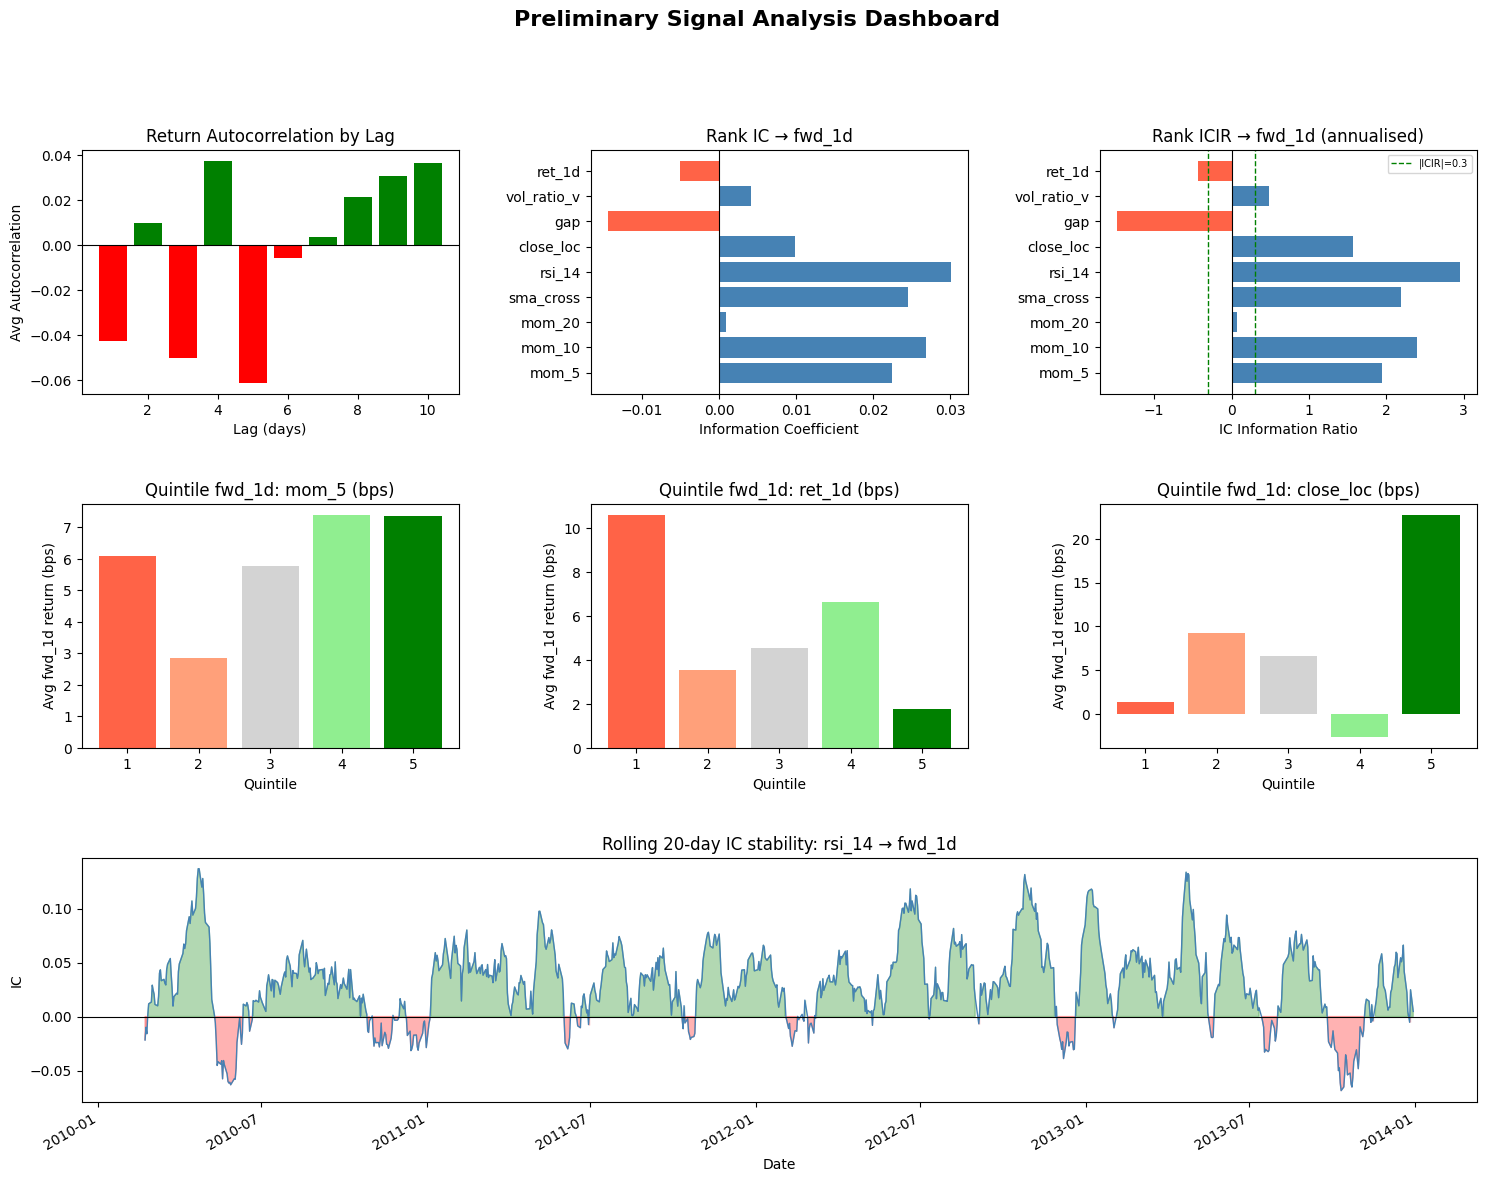

In [33]:
# ── 8. Plot Summary Dashboard ─────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Preliminary Signal Analysis Dashboard", fontsize=16, fontweight='bold')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 8a. Autocorrelation
ax1 = fig.add_subplot(gs[0, 0])
lags_list = list(autocorrs.keys())
ac_vals   = list(autocorrs.values())
colors    = ['green' if v > 0 else 'red' for v in ac_vals]
ax1.bar(lags_list, ac_vals, color=colors)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title("Return Autocorrelation by Lag")
ax1.set_xlabel("Lag (days)")
ax1.set_ylabel("Avg Autocorrelation")

# 8b. IC bar chart
ax2 = fig.add_subplot(gs[0, 1])
feats_plot = list(rank_results.keys())
ic1_vals   = [rank_results[f][0] for f in feats_plot]
colors2    = ['steelblue' if v > 0 else 'tomato' for v in ic1_vals]
ax2.barh(feats_plot, ic1_vals, color=colors2)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title("Rank IC → fwd_1d")
ax2.set_xlabel("Information Coefficient")

# 8c. ICIR bar chart
ax3 = fig.add_subplot(gs[0, 2])
icir1_vals = [rank_results[f][1] for f in feats_plot]
colors3    = ['steelblue' if v > 0 else 'tomato' for v in icir1_vals]
ax3.barh(feats_plot, icir1_vals, color=colors3)
ax3.axvline(0, color='black', linewidth=0.8)
ax3.axvline(0.3, color='green', linewidth=1, linestyle='--', label='|ICIR|=0.3')
ax3.axvline(-0.3, color='green', linewidth=1, linestyle='--')
ax3.set_title("Rank ICIR → fwd_1d (annualised)")
ax3.set_xlabel("IC Information Ratio")
ax3.legend(fontsize=7)

# 8d. Decile spread: mom_5
ax4 = fig.add_subplot(gs[1, 0])
sp = decile_spread(df, 'mom_5', 'fwd_1d')
ax4.bar(range(1, len(sp)+1), sp.values * 10000,
        color=['tomato','lightsalmon','lightgrey','lightgreen','green'])
ax4.set_title("Quintile fwd_1d: mom_5 (bps)")
ax4.set_xlabel("Quintile"); ax4.set_ylabel("Avg fwd_1d return (bps)")

# 8e. Decile spread: ret_1d (mean reversion)
ax5 = fig.add_subplot(gs[1, 1])
sp2 = decile_spread(df, 'ret_1d', 'fwd_1d')
ax5.bar(range(1, len(sp2)+1), sp2.values * 10000,
        color=['tomato','lightsalmon','lightgrey','lightgreen','green'])
ax5.set_title("Quintile fwd_1d: ret_1d (bps)")
ax5.set_xlabel("Quintile"); ax5.set_ylabel("Avg fwd_1d return (bps)")

# 8f. Decile spread: close_loc
ax6 = fig.add_subplot(gs[1, 2])
sp3 = decile_spread(df, 'close_loc', 'fwd_1d')
ax6.bar(range(1, len(sp3)+1), sp3.values * 10000,
        color=['tomato','lightsalmon','lightgrey','lightgreen','green'])
ax6.set_title("Quintile fwd_1d: close_loc (bps)")
ax6.set_xlabel("Quintile"); ax6.set_ylabel("Avg fwd_1d return (bps)")

# 8g. IC stability over time for top signal
ax7 = fig.add_subplot(gs[2, :])
top_feat = max(rank_results, key=lambda f: abs(rank_results[f][1]))
rolling_ic = df.dropna(subset=[top_feat, 'fwd_1d']).groupby('date').apply(
    lambda x: x[top_feat].rank().corr(x['fwd_1d'].rank()) if len(x) >= 10 else np.nan
).rolling(20).mean()
rolling_ic.plot(ax=ax7, color='steelblue', linewidth=1)
ax7.axhline(0, color='black', linewidth=0.8)
ax7.fill_between(rolling_ic.index, rolling_ic, 0,
                 where=(rolling_ic > 0), alpha=0.3, color='green')
ax7.fill_between(rolling_ic.index, rolling_ic, 0,
                 where=(rolling_ic < 0), alpha=0.3, color='red')
ax7.set_title(f"Rolling 20-day IC stability: {top_feat} → fwd_1d")
ax7.set_ylabel("IC"); ax7.set_xlabel("Date")


In [34]:
# ── 9. Summary & Strategy Recommendations ─────────────────────────────────────
print("\n" + "="*60)
print("SUMMARY & STRATEGY RECOMMENDATIONS")
print("="*60)

best_feat = max(rank_results, key=lambda f: abs(rank_results[f][1]))
best_ic, best_icir, best_ic5, best_icir5 = rank_results[best_feat]
print(f"\n  Strongest signal : {best_feat}")
print(f"  IC (1d horizon)  : {best_ic:+.4f}")
print(f"  ICIR (1d)        : {best_icir:+.4f}")


SUMMARY & STRATEGY RECOMMENDATIONS

  Strongest signal : rsi_14
  IC (1d horizon)  : +0.0300
  ICIR (1d)        : +2.9453
